<a href="https://colab.research.google.com/github/Sudarshan-07-rl/Face-Recognition-PCA-ANN/blob/main/aiprogram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries imported successfully.
Dataset extracted successfully.
Total image files found: 450
Images loaded: 450
Image shape: (450, 64, 64)
Number of people: 9
People: ['Aamir' 'Ajay' 'Akshay' 'Alia' 'Amitabh' 'Deepika' 'Disha' 'Farhan'
 'Ileana']


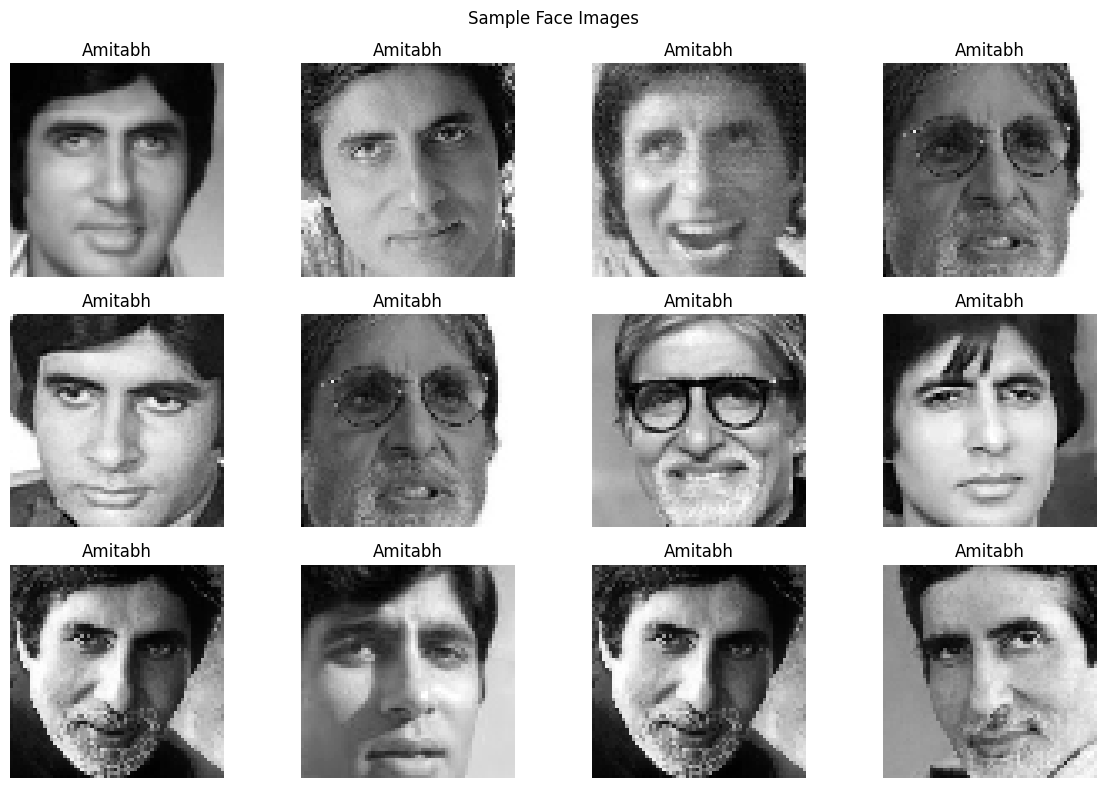


FACE DATABASE
Pixels per image: 4096
Number of images: 450
Face Database shape: (4096, 450)


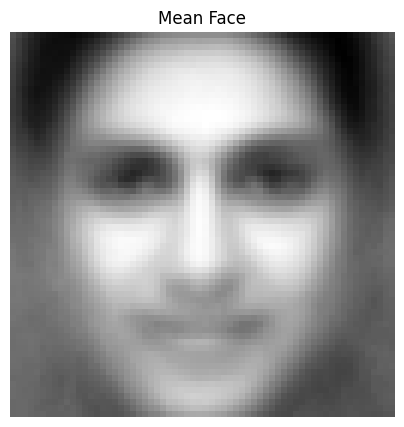

Mean-zero data shape: (4096, 450)
Surrogate covariance shape: (450, 450)
Eigenvalues shape: (450,)
Eigenvectors shape: (450, 450)


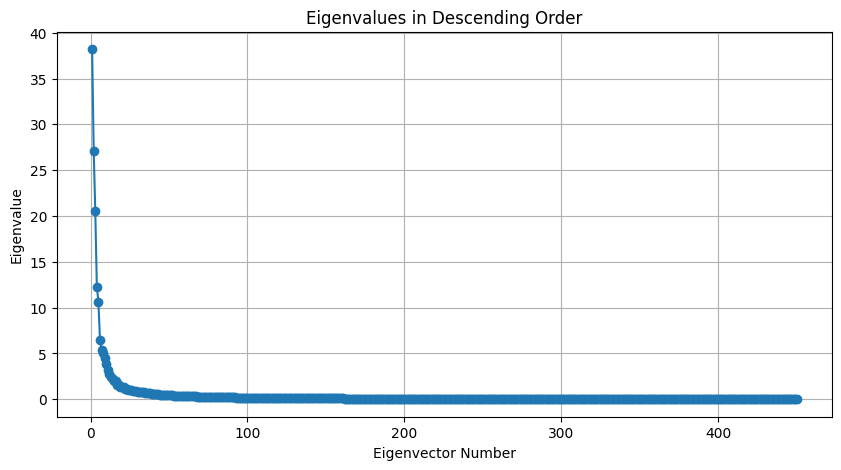

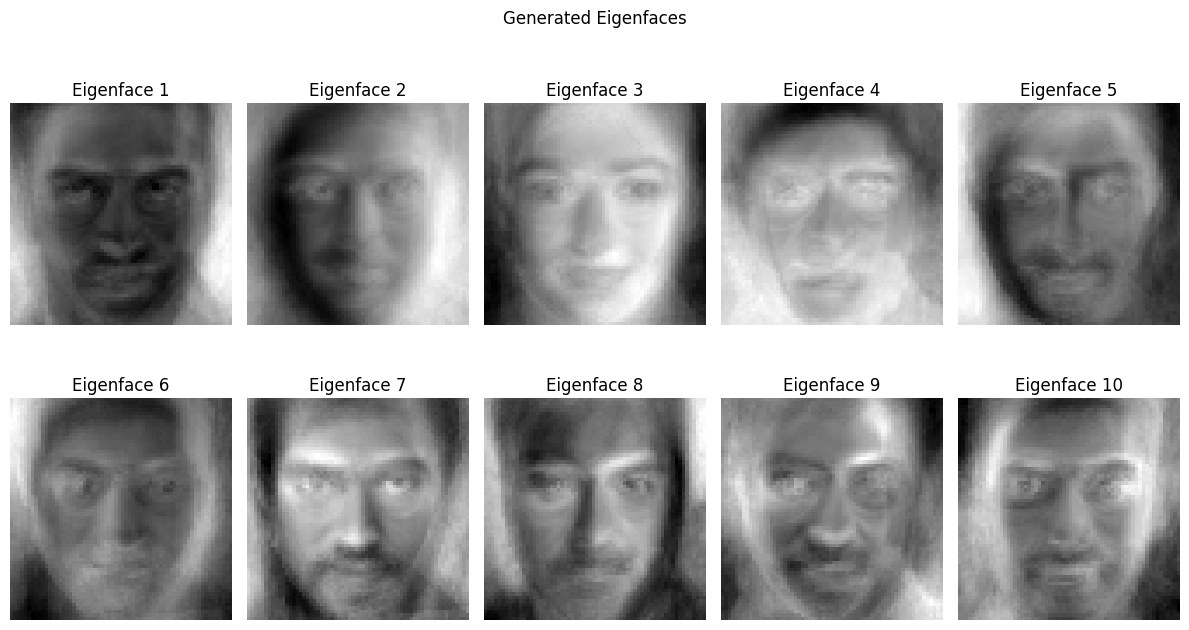


LABEL INFORMATION
0 -> Aamir
1 -> Ajay
2 -> Akshay
3 -> Alia
4 -> Amitabh
5 -> Deepika
6 -> Disha
7 -> Farhan
8 -> Ileana

Training samples: 270
Testing samples: 180

----------------------------------------
Testing k = 5
Accuracy: 40.0 %

----------------------------------------
Testing k = 10
Accuracy: 39.44 %

----------------------------------------
Testing k = 15
Accuracy: 44.44 %

----------------------------------------
Testing k = 20
Accuracy: 50.56 %

----------------------------------------
Testing k = 25
Accuracy: 55.56 %

----------------------------------------
Testing k = 30
Accuracy: 57.22 %

----------------------------------------
Testing k = 40
Accuracy: 53.89 %

----------------------------------------
Testing k = 50
Accuracy: 61.11 %

ACCURACY RESULTS
--------------------------------
k              Accuracy (%)
--------------------------------
5              40.00
10             39.44
15             44.44
20             50.56
25             55.56
30             57.

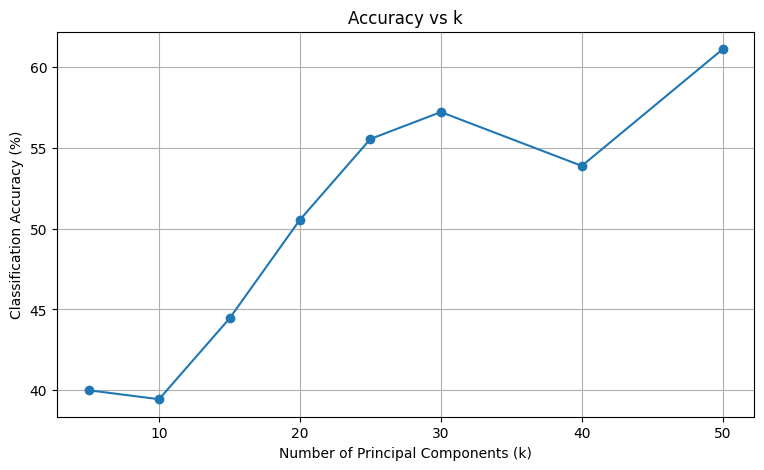


Selected k: 50
Measured accuracy: 61.11 %

Training final ANN...
Epoch: 100 Loss: 1.738835
Epoch: 200 Loss: 1.466287
Epoch: 300 Loss: 1.277041
Epoch: 400 Loss: 1.130843
Epoch: 500 Loss: 1.011843
Epoch: 600 Loss: 0.912527
Epoch: 700 Loss: 0.828262
Epoch: 800 Loss: 0.755975
Epoch: 900 Loss: 0.693484
Epoch: 1000 Loss: 0.638981
Epoch: 1100 Loss: 0.591094
Epoch: 1200 Loss: 0.548757
Epoch: 1300 Loss: 0.511042
Epoch: 1400 Loss: 0.477198
Epoch: 1500 Loss: 0.446645

FINAL TEST RESULT
--------------------------------
Training images: 270
Testing images : 180
PCA components : 50
Final Accuracy : 61.11 %


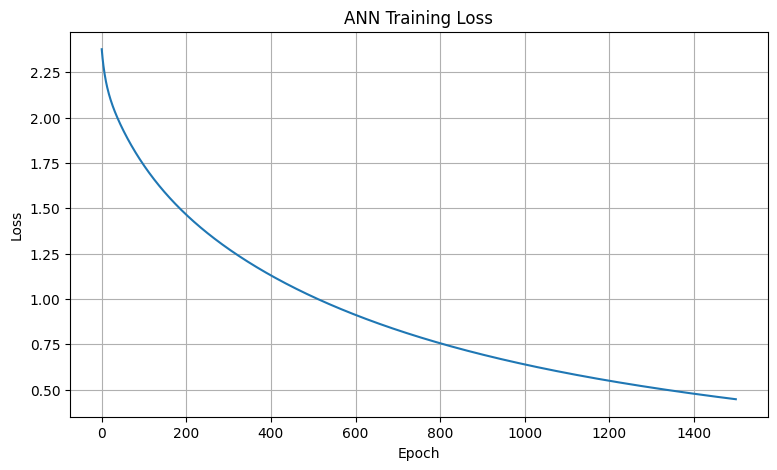


PREDICTION RESULTS
--------------------------------
Actual: Aamir | Predicted: Deepika | Confidence: 62.17 %
Actual: Aamir | Predicted: Ajay | Confidence: 80.55 %
Actual: Aamir | Predicted: Deepika | Confidence: 37.55 %
Actual: Aamir | Predicted: Aamir | Confidence: 41.76 %
Actual: Aamir | Predicted: Aamir | Confidence: 35.86 %
Actual: Aamir | Predicted: Amitabh | Confidence: 63.38 %
Actual: Aamir | Predicted: Aamir | Confidence: 53.21 %
Actual: Aamir | Predicted: Aamir | Confidence: 40.8 %
Actual: Aamir | Predicted: Akshay | Confidence: 31.85 %
Actual: Aamir | Predicted: Aamir | Confidence: 70.1 %
Actual: Aamir | Predicted: Aamir | Confidence: 65.01 %
Actual: Aamir | Predicted: Aamir | Confidence: 77.65 %
Actual: Aamir | Predicted: Ajay | Confidence: 52.81 %
Actual: Aamir | Predicted: Aamir | Confidence: 47.89 %
Actual: Aamir | Predicted: Aamir | Confidence: 36.67 %
Actual: Aamir | Predicted: Aamir | Confidence: 75.04 %
Actual: Aamir | Predicted: Aamir | Confidence: 69.09 %
Actual: A

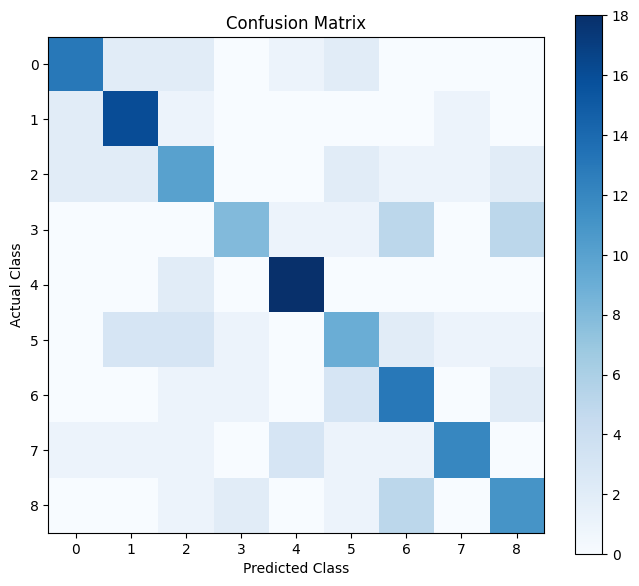


Upload a test face image:


Saving face_38.jpg to face_38.jpg
Uploaded: face_38.jpg


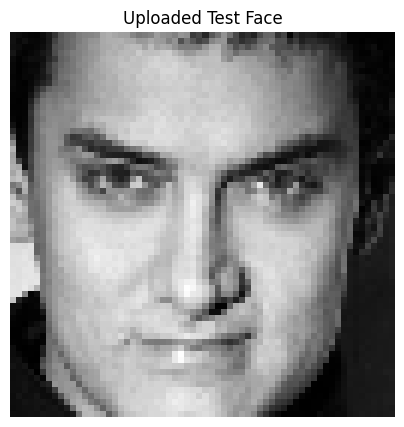

Test image vector shape: (4096, 1)
Mean-zero test image shape: (4096, 1)
Projected test face shape: (50, 1)

FACE RECOGNITION RESULT
--------------------------------
Predicted person: Aamir
Confidence: 65.01 %
RESULT: NOT ENROLLED PERSON

PCA + ANN FACE RECOGNITION SUMMARY
Total images     : 450
Total persons    : 9
Image size       : 64 x 64
Pixels/image     : 4096
Covariance size  : (450, 450)
Selected k       : 50
Training images  : 270
Testing images   : 180
Final accuracy   : 61.11 %

PCA + ANN Face Recognition completed successfully.


In [ ]:
import os
import zipfile
import urllib.request
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("Libraries imported successfully.")

# ===============================================s=================
# 1. DOWNLOAD DATASET
# ================================================================

URL = "https://github.com/robaita/introduction_to_machine_learning/raw/main/dataset.zip"
ZIP_PATH = "/content/dataset.zip"
DATASET_PATH = "/content/dataset"

print("Downloading dataset...")
urllib.request.urlretrieve(URL, ZIP_PATH)

os.makedirs(DATASET_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(DATASET_PATH)

print("Dataset extracted successfully.")

# ================================================================
# 2. FIND AND LOAD IMAGES
# ================================================================

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.pgm', '.tif', '.tiff')

image_files = []

for root, dirs, files_list in os.walk(DATASET_PATH):
    for file in files_list:
        if file.lower().endswith(image_extensions):
            image_files.append(os.path.join(root, file))

print("Total image files found:", len(image_files))

IMG_WIDTH = 64
IMG_HEIGHT = 64
IMG_SIZE = (IMG_WIDTH, IMG_HEIGHT)

images = []
labels = []
valid_paths = []

for path in image_files:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float64) / 255.0

    images.append(img)
    labels.append(os.path.basename(os.path.dirname(path)))
    valid_paths.append(path)

images = np.array(images)
labels = np.array(labels)

if len(images) == 0:
    raise ValueError("No images were found in the dataset.")

unique_people = np.unique(labels)

if len(unique_people) < 2:
    raise ValueError("At least two different people are required.")

print("Images loaded:", len(images))
print("Image shape:", images.shape)
print("Number of people:", len(unique_people))
print("People:", unique_people)

# ================================================================
# 3. DISPLAY SAMPLE FACES
# ================================================================

number_to_display = min(12, len(images))

plt.figure(figsize=(12, 8))

for i in range(number_to_display):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(str(labels[i]))
    plt.axis('off')

plt.suptitle("Sample Face Images")
plt.tight_layout()
plt.show()

# ================================================================
# 4. FACE DATABASE
# ================================================================

p = len(images)
mn = IMG_WIDTH * IMG_HEIGHT

Face_Db = images.reshape(p, mn).T

print("\nFACE DATABASE")
print("Pixels per image:", mn)
print("Number of images:", p)
print("Face Database shape:", Face_Db.shape)

# ================================================================
# 5. MEAN FACE
# ================================================================

M = np.mean(Face_Db, axis=1, keepdims=True)

mean_face = M.reshape(IMG_HEIGHT, IMG_WIDTH)

plt.figure(figsize=(5, 5))
plt.imshow(mean_face, cmap='gray')
plt.title("Mean Face")
plt.axis('off')
plt.show()

# ================================================================
# 6. MEAN ZERO
# ================================================================

Delta = Face_Db - M

print("Mean-zero data shape:", Delta.shape)

# ================================================================
# 7. SURROGATE COVARIANCE
# ================================================================

C = (Delta.T @ Delta) / p

print("Surrogate covariance shape:", C.shape)

# ================================================================
# 8. EIGENVALUES AND EIGENVECTORS
# ================================================================

eigenvalues, eigenvectors = np.linalg.eigh(C)

indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[indices]
eigenvectors = eigenvectors[:, indices]

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o')
plt.xlabel("Eigenvector Number")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalues in Descending Order")
plt.grid()
plt.show()

# ================================================================
# 9. GENERATE EIGENFACES
# ================================================================

def generate_eigenfaces(k):
    Psi = eigenvectors[:, :k]
    Phi = Psi.T @ Delta.T

    norms = np.linalg.norm(Phi, axis=1, keepdims=True)
    Phi = Phi / (norms + 1e-12)

    return Phi

display_k = min(10, p)
Phi = generate_eigenfaces(display_k)

plt.figure(figsize=(12, 7))

for i in range(display_k):
    eigenface = Phi[i].reshape(IMG_HEIGHT, IMG_WIDTH)

    plt.subplot(2, 5, i + 1)
    plt.imshow(eigenface, cmap='gray')
    plt.title("Eigenface " + str(i + 1))
    plt.axis('off')

plt.suptitle("Generated Eigenfaces")
plt.tight_layout()
plt.show()

# ================================================================
# 10. FACE SIGNATURES
# ================================================================

def generate_signatures(k):
    Phi = generate_eigenfaces(k)
    return Phi @ Delta

# ================================================================
# 11. NUMERIC LABELS
# ================================================================

label_to_number = {
    person: i for i, person in enumerate(unique_people)
}

numeric_labels = np.array([
    label_to_number[label] for label in labels
])

print("\nLABEL INFORMATION")

for person, number in label_to_number.items():
    print(number, "->", person)

# ================================================================
# 12. 60% TRAIN / 40% TEST SPLIT
# ================================================================

def train_test_split_per_person(labels, train_ratio=0.60, random_seed=42):

    rng = np.random.default_rng(random_seed)

    train_indices = []
    test_indices = []

    for person in np.unique(labels):

        indices = np.where(labels == person)[0]
        indices = indices.copy()
        rng.shuffle(indices)

        n_train = int(len(indices) * train_ratio)
        n_train = max(1, n_train)

        if len(indices) > 1:
            n_train = min(n_train, len(indices) - 1)

        train_indices.extend(indices[:n_train])
        test_indices.extend(indices[n_train:])

    return np.array(train_indices), np.array(test_indices)

train_indices, test_indices = train_test_split_per_person(
    labels,
    train_ratio=0.60,
    random_seed=42
)

print("\nTraining samples:", len(train_indices))
print("Testing samples:", len(test_indices))

# ================================================================
# 13. ANN USING BACKPROPAGATION
# ================================================================

class ANN_Backpropagation:

    def __init__(self, input_size, hidden_size, output_size,
                 learning_rate=0.05, epochs=1000):

        self.learning_rate = learning_rate
        self.epochs = epochs

        rng = np.random.default_rng(42)

        limit1 = np.sqrt(6 / (input_size + hidden_size))
        limit2 = np.sqrt(6 / (hidden_size + output_size))

        self.W1 = rng.uniform(
            -limit1, limit1, (input_size, hidden_size)
        )
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = rng.uniform(
            -limit2, limit2, (hidden_size, output_size)
        )
        self.b2 = np.zeros((1, output_size))

    def sigmoid(self, x):
        x = np.clip(x, -50, 50)
        return 1 / (1 + np.exp(-x))

    def softmax(self, x):
        x = x - np.max(x, axis=1, keepdims=True)
        exp_x = np.exp(x)
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):

        Z1 = X @ self.W1 + self.b1
        A1 = self.sigmoid(Z1)

        Z2 = A1 @ self.W2 + self.b2
        A2 = self.softmax(Z2)

        return Z1, A1, Z2, A2

    def train(self, X, Y, verbose=False):

        n = X.shape[0]
        loss_history = []

        for epoch in range(self.epochs):

            Z1, A1, Z2, A2 = self.forward(X)

            A2_safe = np.clip(A2, 1e-12, 1.0)

            loss = -np.mean(
                np.sum(Y * np.log(A2_safe), axis=1)
            )

            loss_history.append(loss)

            dZ2 = A2 - Y

            dW2 = (A1.T @ dZ2) / n
            db2 = np.mean(dZ2, axis=0, keepdims=True)

            dA1 = dZ2 @ self.W2.T
            dZ1 = dA1 * A1 * (1 - A1)

            dW1 = (X.T @ dZ1) / n
            db1 = np.mean(dZ1, axis=0, keepdims=True)

            self.W2 -= self.learning_rate * dW2
            self.b2 -= self.learning_rate * db2

            self.W1 -= self.learning_rate * dW1
            self.b1 -= self.learning_rate * db1

            if verbose and (epoch + 1) % 100 == 0:
                print(
                    "Epoch:", epoch + 1,
                    "Loss:", round(loss, 6)
                )

        return loss_history

    def predict(self, X):

        _, _, _, probabilities = self.forward(X)

        predictions = np.argmax(probabilities, axis=1)
        confidence = np.max(probabilities, axis=1)

        return predictions, confidence

# ================================================================
# 14. ONE-HOT ENCODING
# ================================================================

def one_hot_encode(y, number_of_classes):

    Y = np.zeros((len(y), number_of_classes))

    Y[np.arange(len(y)), y] = 1

    return Y

# ================================================================
# 15. ACCURACY VS k EXPERIMENT
# ================================================================

possible_k = [5, 10, 15, 20, 25, 30, 40, 50]

k_values = [k for k in possible_k if k <= p]

if len(k_values) == 0:
    k_values = [max(1, p // 2)]

accuracies = []
results = []

for k in k_values:

    print("\n----------------------------------------")
    print("Testing k =", k)

    signatures = generate_signatures(k)
    X = signatures.T

    X_train = X[train_indices]
    X_test = X[test_indices]

    y_train = numeric_labels[train_indices]
    y_test = numeric_labels[test_indices]

    number_of_classes = len(unique_people)

    Y_train = one_hot_encode(
        y_train,
        number_of_classes
    )

    ann = ANN_Backpropagation(
        input_size=k,
        hidden_size=32,
        output_size=number_of_classes,
        learning_rate=0.05,
        epochs=1000
    )

    ann.train(X_train, Y_train)

    predictions, confidence = ann.predict(X_test)

    accuracy = np.mean(predictions == y_test) * 100

    accuracies.append(accuracy)
    results.append((k, accuracy))

    print("Accuracy:", round(accuracy, 2), "%")

# ================================================================
# 16. ACCURACY TABLE
# ================================================================

print("\nACCURACY RESULTS")
print("--------------------------------")
print("{:<15}{}".format("k", "Accuracy (%)"))
print("--------------------------------")

for k, accuracy in results:
    print("{:<15}{:.2f}".format(k, accuracy))

# ================================================================
# 17. ACCURACY VS k GRAPH
# ================================================================

plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    accuracies,
    marker='o'
)

plt.xlabel("Number of Principal Components (k)")
plt.ylabel("Classification Accuracy (%)")
plt.title("Accuracy vs k")
plt.grid()
plt.show()

# ================================================================
# 18. FINAL MODEL
# ================================================================

best_index = np.argmax(accuracies)
FINAL_K = k_values[best_index]

print("\nSelected k:", FINAL_K)
print("Measured accuracy:",
      round(accuracies[best_index], 2), "%")

final_signatures = generate_signatures(FINAL_K)
X_final = final_signatures.T

X_train_final = X_final[train_indices]
X_test_final = X_final[test_indices]

y_train_final = numeric_labels[train_indices]
y_test_final = numeric_labels[test_indices]

number_of_classes = len(unique_people)

Y_train_final = one_hot_encode(
    y_train_final,
    number_of_classes
)

final_ann = ANN_Backpropagation(
    input_size=FINAL_K,
    hidden_size=32,
    output_size=number_of_classes,
    learning_rate=0.05,
    epochs=1500
)

print("\nTraining final ANN...")

final_loss_history = final_ann.train(
    X_train_final,
    Y_train_final,
    verbose=True
)

# ================================================================
# 19. FINAL TESTING
# ================================================================

final_predictions, final_confidence = final_ann.predict(
    X_test_final
)

final_accuracy = np.mean(
    final_predictions == y_test_final
) * 100

print("\nFINAL TEST RESULT")
print("--------------------------------")
print("Training images:", len(X_train_final))
print("Testing images :", len(X_test_final))
print("PCA components :", FINAL_K)
print("Final Accuracy :", round(final_accuracy, 2), "%")

# ================================================================
# 20. ANN LOSS GRAPH
# ================================================================

plt.figure(figsize=(9, 5))
plt.plot(final_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training Loss")
plt.grid()
plt.show()

# ================================================================
# 21. PREDICTION RESULTS
# ================================================================

print("\nPREDICTION RESULTS")
print("--------------------------------")

for i in range(len(test_indices)):

    actual_person = unique_people[y_test_final[i]]
    predicted_person = unique_people[final_predictions[i]]

    conf = final_confidence[i] * 100

    print(
        "Actual:", actual_person,
        "| Predicted:", predicted_person,
        "| Confidence:", round(conf, 2), "%"
    )

# ================================================================
# 22. CONFUSION MATRIX
# ================================================================

confusion_matrix = np.zeros(
    (number_of_classes, number_of_classes),
    dtype=int
)

for actual, predicted in zip(
    y_test_final,
    final_predictions
):
    confusion_matrix[actual, predicted] += 1

print("\nCONFUSION MATRIX")
print(confusion_matrix)

plt.figure(figsize=(8, 7))
plt.imshow(confusion_matrix, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()
plt.show()

# ================================================================
# 23. UPLOAD A TEST FACE
# ================================================================

print("\nUpload a test face image:")

uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No image uploaded.")

test_filename = list(uploaded.keys())[0]

print("Uploaded:", test_filename)

# ================================================================
# 24. READ TEST IMAGE
# ================================================================

test_img = cv2.imread(
    test_filename,
    cv2.IMREAD_GRAYSCALE
)

if test_img is None:
    raise ValueError("Unable to read uploaded image.")

test_img = cv2.resize(
    test_img,
    IMG_SIZE
)

test_img = test_img.astype(
    np.float64
) / 255.0

plt.figure(figsize=(5, 5))
plt.imshow(test_img, cmap='gray')
plt.title("Uploaded Test Face")
plt.axis('off')
plt.show()

# ================================================================
# 25. MEAN ZERO TEST IMAGE
# ================================================================

I1 = test_img.reshape(-1, 1)

I2 = I1 - M

print("Test image vector shape:", I1.shape)
print("Mean-zero test image shape:", I2.shape)

# ================================================================
# 26. PROJECT TEST IMAGE TO EIGENFACES
# ================================================================

final_Phi = generate_eigenfaces(FINAL_K)

Omega = final_Phi @ I2

print("Projected test face shape:", Omega.shape)

# ================================================================
# 27. ANN PREDICTION
# ================================================================

test_signature = Omega.T

predicted_class, predicted_confidence = final_ann.predict(
    test_signature
)

predicted_class = predicted_class[0]
predicted_confidence = predicted_confidence[0]

predicted_person = unique_people[predicted_class]

# ================================================================
# 28. IMPOSTER DETECTION
# ================================================================

CONFIDENCE_THRESHOLD = 0.70

print("\nFACE RECOGNITION RESULT")
print("--------------------------------")
print("Predicted person:", predicted_person)
print(
    "Confidence:",
    round(predicted_confidence * 100, 2),
    "%"
)

if predicted_confidence < CONFIDENCE_THRESHOLD:
    print("RESULT: NOT ENROLLED PERSON")
else:
    print("RESULT:", predicted_person)

# ================================================================
# 29. FINAL SUMMARY
# ================================================================

print("\n================================================")
print("PCA + ANN FACE RECOGNITION SUMMARY")
print("================================================")

print("Total images     :", p)
print("Total persons    :", len(unique_people))
print("Image size       :", IMG_WIDTH, "x", IMG_HEIGHT)
print("Pixels/image     :", mn)
print("Covariance size  :", C.shape)
print("Selected k       :", FINAL_K)
print("Training images  :", len(train_indices))
print("Testing images   :", len(test_indices))
print("Final accuracy   :", round(final_accuracy, 2), "%")

print("\nPCA + ANN Face Recognition completed successfully.")
